In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import numpy as np

In [16]:
# Load the data
data = pd.read_csv('clean_finished_paths.csv')

print(data.shape)
print(data.columns)

(51249, 16)
Index(['Unnamed: 0', 'hashedIpAddress', 'timestamp', 'durationInSec', 'path',
       'rating', 'nb_back_clicks', 'nb_clicks', 'path_length', 'source',
       'target', 'source_category', 'target_category',
       'source_general_category', 'target_general_category', 'clean_path'],
      dtype='object')


In [17]:
data.describe()

,Unnamed: 0,timestamp,durationInSec,rating,nb_back_clicks,nb_clicks,path_length
count,51249.000000,5.124900e+04,51249.000000,51249.000000,51249.000000,51249.000000,51249.000000
mean,25634.648091,1.296390e+09,158.256044,0.816738,0.400398,5.757381,4.956585
std,14808.057694,4.935694e+07,360.793518,1.823400,1.450585,4.680603,3.289866
min,0.000000,1.219095e+09,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,12813.000000,1.250109e+09,60.000000,-1.000000,0.000000,4.000000,3.000000
50%,25629.000000,1.283896e+09,107.000000,1.000000,0.000000,5.000000,4.000000
75%,38441.000000,1.345233e+09,183.000000,2.000000,0.000000,7.000000,6.000000
max,51317.000000,1.389823e+09,35091.000000,5.000000,45.000000,434.000000,404.000000


In [18]:
# Initialize a directed graph
G = nx.DiGraph()

# Add edges from the data: each edge goes from 'source' to 'target'
# NetworkX will automatically create nodes when you add edges
for _, row in data.iterrows():
    # Add edge between each pair of articles in the path
    path = row['clean_path'].split(",")
    for i in range(len(path) - 1):
         # Increment edge weight if the edge already exists, otherwise set it to 1
        if G.has_edge(path[i], path[i + 1]):
            G[path[i]][path[i + 1]]['weight'] += 1
        else:
            G.add_edge(path[i], path[i + 1], weight=1)

# Print basic info about the graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())

# Get the degree of each node as a list
degrees = [degree for _, degree in G.degree()]

# Calculate the mean degree
mean_degree = np.mean(degrees)

# Calculate the standard deviation of the degrees
std_dev_degree = np.std(degrees)

# Calculate the standard error
standard_error = std_dev_degree / np.sqrt(len(degrees))

# Print the standard error of the average degree
print("Standard error of the average degree:", standard_error)

# Convert directed graph to undirected graph
G_undirected = G.to_undirected()

# 1. Calculate average clustering coefficient and path length of the Wikipedia graph
avg_clustering_coeff = nx.average_clustering(G_undirected)
try:
    avg_path_length = nx.average_shortest_path_length(G_undirected)
except nx.NetworkXError:
    # Handle disconnected components
    avg_path_length = np.mean([nx.average_shortest_path_length(G_undirected.subgraph(c).copy()) 
                               for c in nx.connected_components(G_undirected) if len(c) > 1])

print("Wikipedia Graph - Average Clustering Coefficient:", avg_clustering_coeff)
print("Wikipedia Graph - Average Path Length:", avg_path_length)

Number of nodes: 10727
Number of edges: 68732
Average degree: 12.814766477113825
Standard error of the average degree: 0.39541021609365096
Wikipedia Graph - Average Clustering Coefficient: 0.27995962091885934
Wikipedia Graph - Average Path Length: 3.244947039749638


In [8]:
print("Number of paths with back clicks:", len(data[data["nb_back_clicks"] != 0]))

Number of paths with back clicks: 8982


In [5]:
# Get most frequent sources and targets
freq_src = data["source"].value_counts()[:60]
freq_trgt = data["target"].value_counts()[:60]

# Get lists of most frequent sources and targets
top_sources = freq_src.index.tolist()
top_targets = freq_trgt.index.tolist()

# Filter paths that have a source or target in the top lists
subset = data[(data["source"].isin(top_sources)) | (data["target"].isin(top_targets))]

# Check subset size 
print("Subset size:", len(subset))

Subset size: 11753


In [ ]:
# Number of paths with back clicks
print("Number of paths with back clicks:", len(subset[subset["nb_back_clicks"] != 0]))

subset[subset["nb_back_clicks"] != 0]


Number of paths with back clicks: 1800


,Unnamed: 0,hashedIpAddress,timestamp,durationInSec,path,rating,nb_back_clicks,nb_clicks,path_length,source,target,source_category,target_category,source_general_category,target_general_category,clean_path
10,10,4cb0068c36658716,1248654953,253,"['14th_century', 'Time', 'Science', 'Nature', ...",3.0,1,12,10,14th_century,Rainbow,"['History', 'General_history']","['Geography', 'Climate_and_the_Weather']",History,Geography,"['14th_century', 'Time', 'Science', 'Nature', ..."
13,13,0d57c8c57d75e2f5,1283956474,391,"['14th_century', 'Renaissance', 'Empiricism', ...",5.0,4,15,7,14th_century,Rainbow,"['History', 'General_history']","['Geography', 'Climate_and_the_Weather']",History,Geography,"['14th_century', 'Renaissance', 'Empiricism', ..."
14,14,0d57c8c57d75e2f5,1290753904,432,"['14th_century', 'Renaissance', 'Leonardo_da_V...",-1.0,2,8,4,14th_century,Rainbow,"['History', 'General_history']","['Geography', 'Climate_and_the_Weather']",History,Geography,"['14th_century', 'Renaissance', 'Leonardo_da_V..."
16,16,03dc907932cecfc5,1336436263,387,"['14th_century', 'Europe', 'Republic_of_Irelan...",2.0,5,14,4,14th_century,Rainbow,"['History', 'General_history']","['Geography', 'Climate_and_the_Weather']",History,Geography,"['14th_century', 'Time', 'Physics', 'Speed_of_..."
19,19,46021cc81bd7069a,1343940479,246,"['14th_century', 'Time', 'Physics', '<', 'Day'...",-1.0,3,13,7,14th_century,Rainbow,"['History', 'General_history']","['Geography', 'Climate_and_the_Weather']",History,Geography,"['14th_century', 'Time', 'Day', 'Sun', 'Sunlig..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50423,50492,0df33c6a19d497e3,1355868282,123,"['Windows_Vista', 'Bill_Gates', 'Mathematics',...",-1.0,3,8,2,Windows_Vista,Leonardo_da_Vinci,"['IT', 'Software']","['People', 'Engineers_and_inventors']",IT,People,"['Windows_Vista', 'Bill_Gates', 'Leonardo_da_V..."
50668,50737,101779c07d4d00f0,1265215133,348,"['Zambezi', 'South_Africa', '<', 'Germany', 'P...",-1.0,7,17,3,Zambezi,Jesus,"['Geography', 'African_Geography']","['People', 'Religious_figures_and_leaders']",Geography,People,"['Zambezi', 'David_Livingstone', 'Christianity..."
50670,50739,4889fe213307dbde,1309031470,77,"['Zambezi', 'Indian_Ocean', 'Mesopotamia', '<'...",2.0,1,7,5,Zambezi,Jesus,"['Geography', 'African_Geography']","['People', 'Religious_figures_and_leaders']",Geography,People,"['Zambezi', 'Indian_Ocean', 'Ancient_Egypt', '..."
51008,51077,30e5bebf58b2edf0,1249424442,611,"['History_of_painting', 'France', 'United_Stat...",5.0,1,26,24,History_of_painting,Nintendo,"['History', 'General_history']","['Everyday_life', 'Computer_and_Video_games']",History,Everyday_life,"['History_of_painting', 'France', 'United_Stat..."


In [10]:
# Save subset to a new csv
subset.to_csv("subset.csv", index=False)

In [2]:
# Load the subset
data = pd.read_csv('subset.csv')


In [3]:
# Initialize a directed graph
G = nx.DiGraph()

# Add edges from the data: each edge goes from 'source' to 'target'
# NetworkX will automatically create nodes when you add edges
for _, row in data.iterrows():
    # Add edge between each pair of articles in the path
    path = row['clean_path'].split(",")
    for i in range(len(path) - 1):
         # Increment edge weight if the edge already exists, otherwise set it to 1
        if G.has_edge(path[i], path[i + 1]):
            G[path[i]][path[i + 1]]['weight'] += 1
        else:
            G.add_edge(path[i], path[i + 1], weight=1)

# Print basic info about the graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())

# Get the degree of each node as a list
degrees = [degree for _, degree in G.degree()]

# Calculate the mean degree
mean_degree = np.mean(degrees)

# Calculate the standard deviation of the degrees
std_dev_degree = np.std(degrees)

# Calculate the standard error
standard_error = std_dev_degree / np.sqrt(len(degrees))

# Print the standard error of the average degree
print("Standard error of the average degree:", standard_error)


Number of nodes: 4302
Number of edges: 16737
Average degree: 7.781032078103208
Standard error of the average degree: 0.28765723081259775


In [5]:
# Convert directed graph to undirected graph
G_undirected = G.to_undirected()

# 1. Calculate average clustering coefficient and path length of the Wikipedia graph
avg_clustering_coeff = nx.average_clustering(G_undirected)
try:
    avg_path_length = nx.average_shortest_path_length(G_undirected)
except nx.NetworkXError:
    # Handle disconnected components
    avg_path_length = np.mean([nx.average_shortest_path_length(G_undirected.subgraph(c).copy()) 
                               for c in nx.connected_components(G_undirected) if len(c) > 1])

print("Wikipedia Graph - Average Clustering Coefficient:", avg_clustering_coeff)
print("Wikipedia Graph - Average Path Length:", avg_path_length)

Wikipedia Graph - Average Clustering Coefficient: 0.14256028934186715
Wikipedia Graph - Average Path Length: 3.6623294010853


In [14]:
# Set a threshold for filtering edges
weight_threshold = 10  

# Create a new graph with only the significant edges
G_filtered = nx.DiGraph()
for u, v, weight in G.edges(data='weight'):
    if weight > weight_threshold:
        G_filtered.add_edge(u, v, weight=weight)

# Print basic info about the graph
print("Number of nodes of filtered graph:", G_filtered.number_of_nodes())
print("Number of edges of filtered graph:", G_filtered.number_of_edges())
print("Average degree of filtered graph:", sum(dict(G_filtered.degree()).values()) / G_filtered.number_of_nodes())

Number of nodes of filtered graph: 454
Number of edges of filtered graph: 822
Average degree of filtered graph: 3.6211453744493394


In [15]:
# Convert directed graph to undirected graph
G_undirected = G_filtered.to_undirected()

# 1. Calculate average clustering coefficient and path length of the Wikipedia graph
avg_clustering_coeff = nx.average_clustering(G_undirected)
try:
    avg_path_length = nx.average_shortest_path_length(G_undirected)
except nx.NetworkXError:
    # Handle disconnected components
    avg_path_length = np.mean([nx.average_shortest_path_length(G_undirected.subgraph(c).copy()) 
                               for c in nx.connected_components(G_undirected) if len(c) > 1])

print("Wikipedia Graph - Average Clustering Coefficient of filtered graph:", avg_clustering_coeff)
print("Wikipedia Graph - Average Path Length of filtered graph:", avg_path_length)

Wikipedia Graph - Average Clustering Coefficient of filtered graph: 0.11765952652430547
Wikipedia Graph - Average Path Length of filtered graph: 1.2376125292884448


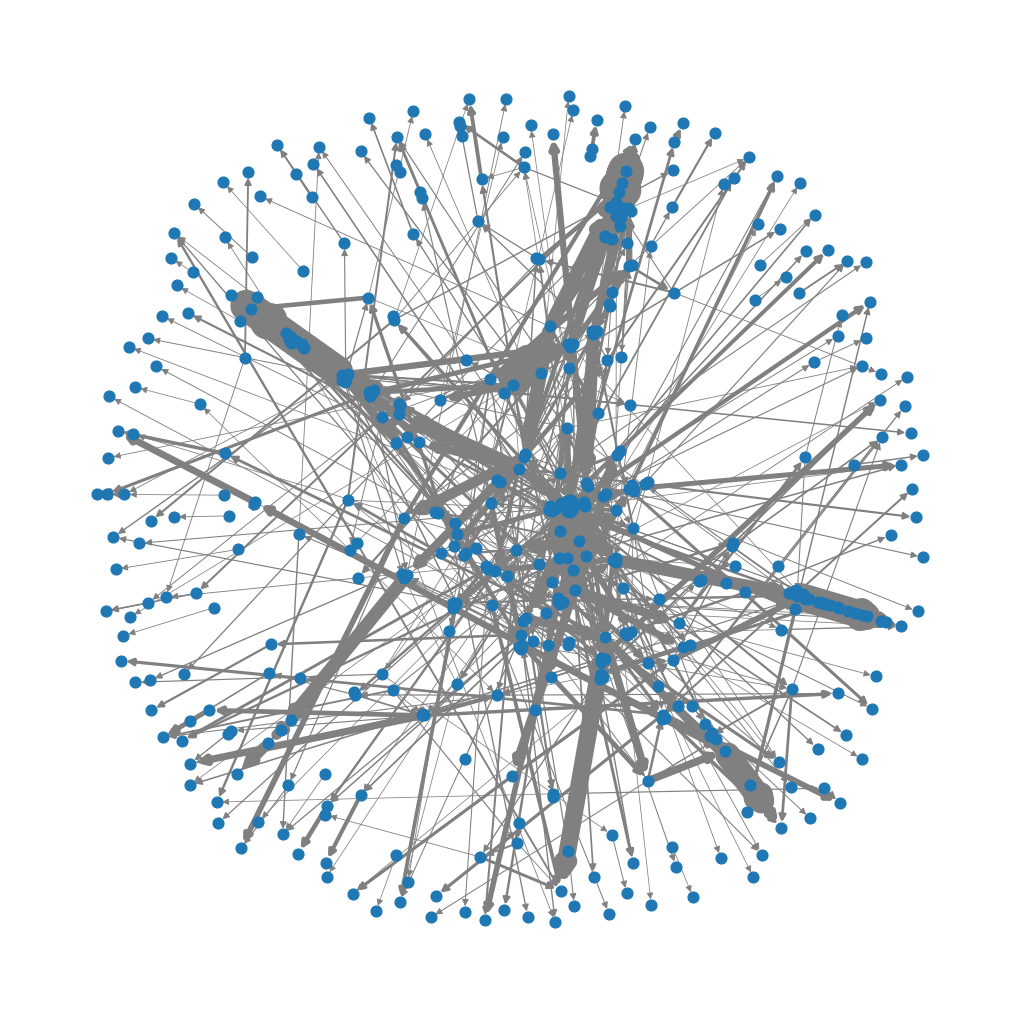

In [25]:
plt.figure(figsize=(10, 10))
# Use edge weight to control the width of edges in the visualization
edge_width = [G_filtered[u][v]['weight'] / 20 for u, v in G_filtered.edges()]
nx.draw(G_filtered, with_labels=False, node_size=60, font_size=8, edge_color='gray', width=edge_width, alpha=1)
plt.show()

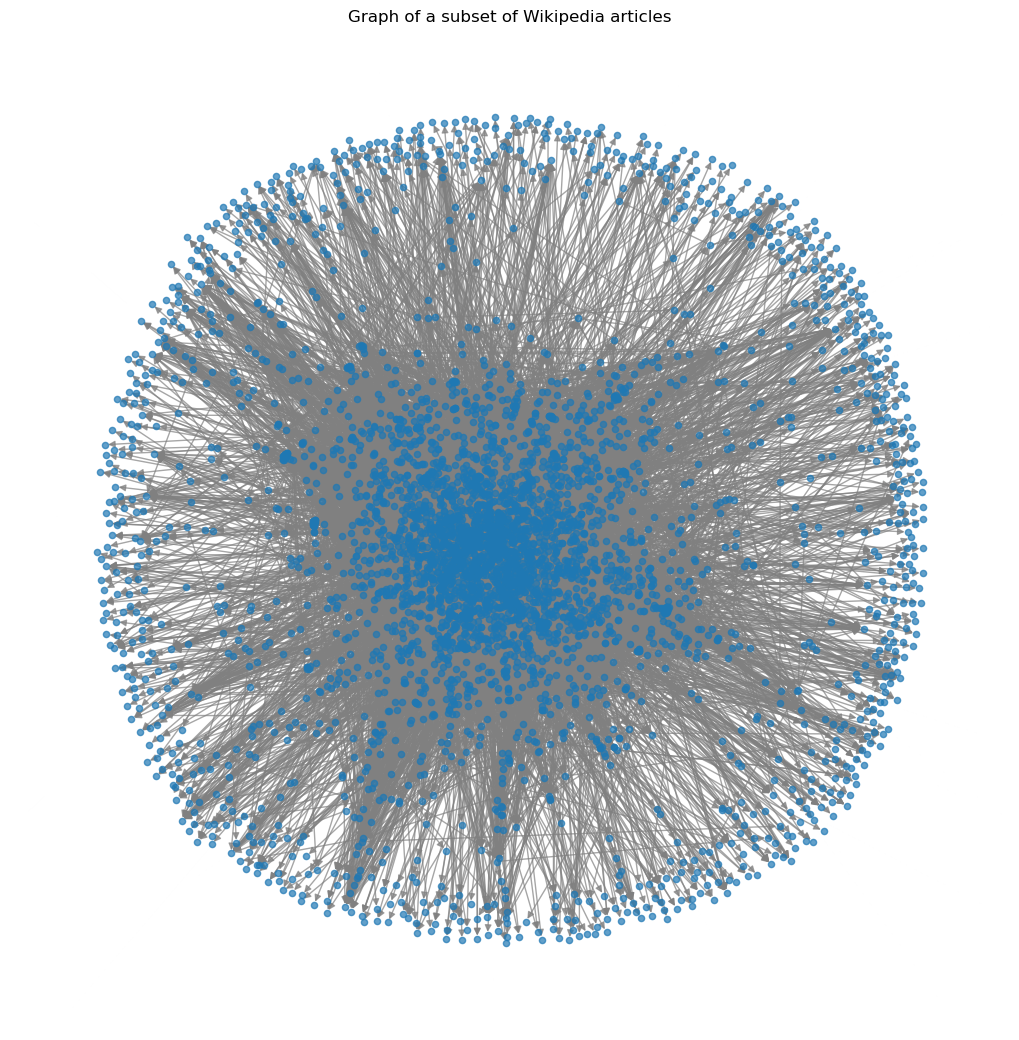

In [24]:
# Visualize the graph
plt.figure(figsize=(10, 10))
nx.draw(G, with_labels=False, node_size=20, font_size=8, edge_color='gray', alpha=0.7)
plt.title("Graph of a subset of Wikipedia articles")
plt.show()